In [1]:
import numpy as np
import matplotlib.pyplot as plt
import allantools 

In [2]:
N = 1000 # Num of points
t = np.logspace(0, 3, 50) # tau values from 1 to 1000

In [3]:
# Generate white noise
freq_white = allantools.noise.white(N)
freq_pink = allantools.noise.pink(N)
freq_rw = allantools.noise.brown(N)

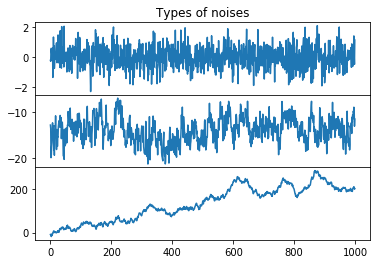

In [4]:
f, (ax1, ax2, ax3) = plt.subplots(3, sharex=True)
ax1.set_title('Types of noises')
ax1.plot(freq_white)
ax2.plot(freq_pink)
ax3.plot(freq_rw)
f.subplots_adjust(hspace=0)
plt.setp([a.get_xticklabels() for a in f.axes[:-1]], visible=False)

# Using convolve for sliding windows

https://stackoverflow.com/questions/13728392/moving-average-or-running-mean

In [5]:
example_array = [1,2,3,4,5]

In [6]:
# case where m = 3
# kernel returns array with 3 elements, each element has a value of 1/3
# during convolution, the kernel array is flipped 
# => doesn't affect because all elements in the kernel array are the same
# first array = 1/3*(1+2+3) = 1/3*(6) = 2
# second array = 1/3*(2+3+4) = 1/3*(9) = 3
# third array = 1/3*(3+4+5) = 1/3*(12) = 4
# using valid so sliding windows will start at the start and end of the freq array
np.convolve(example_array, np.ones(3)/3,'valid')

array([2., 3., 4.])

In [7]:
%%time
N = len(freq_white)
# m array where 3 < m < N/3 
m = np.arange(3,1+round(N//3),1)
# Take tau0 as 1/rate
tau0 = 1
# steps
step = 1
    
# Empty variance array
allanvar = []
# Empty tau values array 
tau = []

CPU times: user 13 µs, sys: 0 ns, total: 13 µs
Wall time: 15 µs


In [8]:
%%time
# Iterate over values of m
for k in range(len(m)): 
    # Sliding windows 
    left = 0 
    right = m[k]
    ybar = []

    while right <= N:
        ybar.append(np.mean(freq_white[left:right]))
        left += step 
        right += step 

CPU times: user 1.38 s, sys: 0 ns, total: 1.38 s
Wall time: 1.38 s


In [9]:
%%time
for k in range(len(m)):
    # Make an array of size m with each item has a value of 1/m 
    kernels = np.ones(m[k])/m[k]
    # Essentially calculating a sum of (1*y0+1*y1+...+1*ym)/m
    ybar_opt = np.convolve(freq_white, kernels, 'valid')

CPU times: user 11.5 ms, sys: 0 ns, total: 11.5 ms
Wall time: 10.7 ms


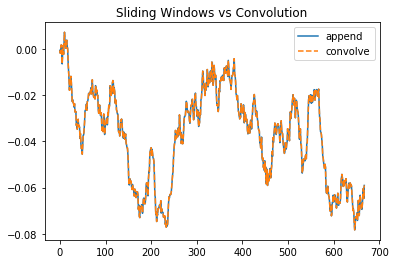

In [10]:
plt.plot(ybar, label='append')
plt.plot(ybar_opt, label='convolve', linestyle='dashed')
plt.title('Sliding Windows vs Convolution')
plt.legend()

# Using np.arange

In [11]:
%%time
for k in range(len(m)): 
    # Sliding windows 
    ybar = []
    kernels = np.ones(m[k])/m[k]
    ybar = np.convolve(freq_white, kernels, 'valid')

    # M is the number of times we can move the averaging window from the beginning to the end
    M = len(ybar)
    
    allanvar = []
    tau = []

    # Calculate allan var 
    outersum = []
    j = 0 
    while j < M-2*m[k]+1:
        i = j
        innersum = []
        while i <= j+m[k]-1:
            innersum.append(ybar[i+m[k]]-ybar[i])
            i += step
        outersum.append(0.5*(np.sum(innersum)/m[k])**2)
        j += step 

    # Calculate allan variance
    allanvar.append(np.sum(outersum)/(M-2*m[k]+1))
        
    # Calculate tau
    tau.append(tau0*m[k])

# Calculate allan std dev
allanstd = np.sqrt(allanvar)
        

CPU times: user 23.3 s, sys: 3.78 ms, total: 23.3 s
Wall time: 23.3 s


In [12]:
%%time
for k in range(len(m)): 
    # Sliding windows 
    ybar = []
    kernels = np.ones(m[k])/m[k]
    ybar = np.convolve(freq_white, kernels, 'valid')

    # M is the number of times we can move the averaging window from the beginning to the end
    M = len(ybar)
    
    allanvar_opt = []
    tau_opt = []

    # Calculate allan var 
    outersum = []
    for j in np.arange(0,M-2*m[k]+1,step):
        innersum = []
        for i in np.arange(j,j+m[k]-1,step):
            innersum.append(ybar[i+m[k]]-ybar[i])
        outersum.append(0.5*(np.sum(innersum)/m[k])**2)

    # Calculate allan variance
    allanvar_opt.append(np.sum(outersum)/(M-2*m[k]+1))
        
    # Calculate tau
    tau_opt.append(tau0*m[k])

# Calculate allan std dev
allanstd_opt = np.sqrt(allanvar)
        

CPU times: user 13.3 s, sys: 32 ms, total: 13.3 s
Wall time: 13.3 s


# Comparasion with original

In [13]:
def allanoadev_ori(y,t,rate):
        
    # === Parameters ===
    
    N = len(y)
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # Take tau0 as 1/rate
    tau0 = 1/rate
    # steps
    step = 1
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []

    # Iterate over values of m
    for k in range(len(m)): 
        # Sliding windows 
        left = 0 
        right = m[k]
        ybar = []

        while right <= N:
            ybar.append(np.mean(y[left:right]))
            left += step 
            right += step 

        # M is the number of times we can move the averaging window from the beginning to the end
        M = len(ybar)

        # Calculate allan var 
        outersum = []
        j = 0 
        while j < M-2*m[k]+1:
            i = j
            innersum = []
            while i <= j+m[k]-1:
                innersum.append(ybar[i+m[k]]-ybar[i])
                i += step
            outersum.append(0.5*(np.sum(innersum)/m[k])**2)
            j += step 

        # Calculate allan variance
        allanvar.append(np.sum(outersum)/(M-2*m[k]+1))
        
        # Calculate tau
        tau.append(tau0*m[k])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd

In [14]:
def allanoadev_opt(y,t,rate):
        
    # === Parameters ===
    
    N = len(y)
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # Take tau0 as 1/rate
    tau0 = 1/rate
    # steps
    step = 1
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []

    # Iterate over values of m
    for k in range(len(m)): 
        kernels = np.ones(m[k])/m[k]
        ybar = np.convolve(y,kernels,'valid')

        # M is the number of times we can move the averaging window from the beginning to the end
        M = len(ybar)

        # Calculate allan var 
        outersum = []
        for j in np.arange(0,M-2*m[k]+1,step):
            innersum = []
            for i in np.arange(j,j+m[k]-1,step):
                innersum.append(ybar[i+m[k]]-ybar[i])
            outersum.append(0.5*(np.sum(innersum)/m[k])**2)

        # Calculate allan variance
        allanvar.append(np.sum(outersum)/(M-2*m[k]+1))
        
        # Calculate tau
        tau.append(tau0*m[k])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd


In [15]:
%%time
tau_white_ori, allanstd_white_ori = allanoadev_ori(freq_white,t,1)

CPU times: user 19.9 s, sys: 0 ns, total: 19.9 s
Wall time: 19.9 s


In [16]:
%%time
tau_white_opt, allanstd_white_opt = allanoadev_opt(freq_white,t,1)

CPU times: user 11.9 s, sys: 36 ms, total: 11.9 s
Wall time: 11.9 s


In [17]:
%%time
tau_pink_ori, allanstd_pink_ori = allanoadev_ori(freq_pink,t,1)

CPU times: user 20 s, sys: 0 ns, total: 20 s
Wall time: 20 s


In [18]:
%%time
tau_pink_opt, allanstd_pink_opt = allanoadev_opt(freq_pink,t,1)

CPU times: user 12.1 s, sys: 20 ms, total: 12.1 s
Wall time: 12.1 s


In [19]:
%%time
tau_rw_ori, allanstd_rw_ori = allanoadev_ori(freq_rw,t,1)

CPU times: user 20 s, sys: 0 ns, total: 20 s
Wall time: 20 s


In [20]:
%%time
tau_rw_opt, allanstd_rw_opt = allanoadev_opt(freq_rw,t,1)

CPU times: user 12 s, sys: 16 ms, total: 12 s
Wall time: 12 s


In [21]:
def allanoadev_ref(freq):
    (taus, adevs, errors, ns) = allantools.oadev(freq, data_type='freq', taus = t)
    return taus, adevs

In [22]:
%%time
tau_white_ref, allanstd_white_ref = allanoadev_ref(freq_white)

CPU times: user 1.34 ms, sys: 1 µs, total: 1.34 ms
Wall time: 1.08 ms


allantools is still faster (uses phase data)

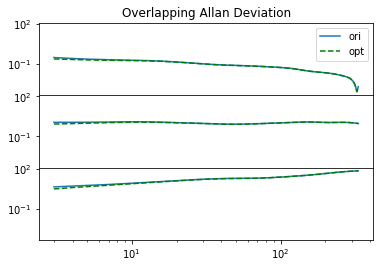

In [23]:
f, (ax1, ax2, ax3) = plt.subplots(3, sharex=True, sharey=True)
ax1.set_title('Overlapping Allan Deviation')
ax1.loglog(tau_white_ori,allanstd_white_ori, label='ori')
#ax1.loglog(tau_white_ref,allanstd_white_ref, label='allantools', linestyle='dashed', color='orange')
ax1.loglog(tau_white_opt,allanstd_white_opt, label='opt',linestyle='dashed', color='green')
ax1.legend()
ax2.loglog(tau_pink_ori,allanstd_pink_ori, label='ori')
ax2.loglog(tau_pink_opt,allanstd_pink_opt, label='opt',linestyle='dashed', color='green')
ax3.loglog(tau_rw_ori,allanstd_rw_ori, label='ori')
ax3.loglog(tau_rw_opt,allanstd_rw_opt, label='opt',linestyle='dashed', color='green')
f.subplots_adjust(hspace=0)
plt.setp([a.get_xticklabels() for a in f.axes[:-1]], visible=False)